In [ ]:
 Design and conduct an experiment to demonstrate the
di culties that sample-average methods have for nonstationary problems. Use a modified
version of the 10-armed testbed in which all the q⇤(a) start out equal and then take
independent random walks (say by adding a normally distributed increment with mean 0
and standard deviation 0.01 to all the q⇤(a) on each step). Prepare plots like Figure 2.2
for an action-value method using sample averages, incrementally computed, and another
action-value method using a constant step-size parameter, ↵ = 0.1. Use " = 0.1 and
longer runs, say of 10,000 steps.

In [5]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 2.2 MB/s  0:00:042.2 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 3.0 MB/s  0:00:012.9 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 2.8 MB/s  0:00:012.8 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]
Note: you may need to restart the kernel to use updated packages.


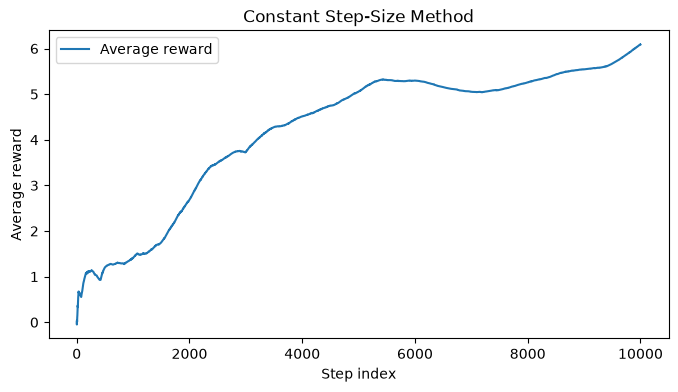

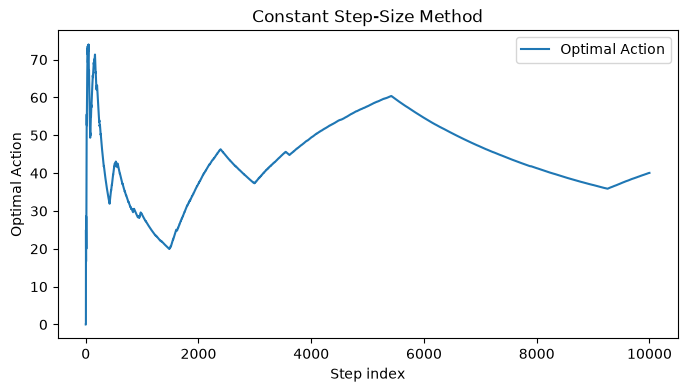

In [33]:
# Let's do RL for bandit problem
# sample averages, incrementally computed
# Qn+1= Qn +1/n(Rn-Qn),
import numpy as np
import matplotlib.pyplot as plt

epsilon = 0.1

Q_values = np.zeros(10)
Q_star_values = np.zeros(10)
N_action = np.zeros(10)
Average_Reward_History = []
optimal_action_percentage = []
total_reward = 0
time_taken_optimal_action = 0
for i in range(1, 10_000):

    # True values perform a random walk
    Q_star_values += np.random.normal(0, 0.1, size=10)

    # Epsilon-greedy action selection
    if np.random.uniform(0, 1) < epsilon:
        action = np.random.choice(10)
    else:
        action = np.argmax(Q_values)

    optimal = np.argmax(Q_star_values)
    if optimal == action:
        time_taken_optimal_action +=1

    optimal_action_percentage.append((time_taken_optimal_action / i)*100)
    # Observe reward
    reward = Q_star_values[action]
    N_action[action] +=1
    # Constant step-size update
    Q_values[action] += (1/N_action[action]) * (
        reward - Q_values[action]
    )

    # Average reward
    total_reward += reward
    Average_Reward_History.append(total_reward / i)


plt.figure(figsize=(8, 4))

plt.plot(
    range(1, 10_000),
    Average_Reward_History,
    label="Average reward"
)

plt.xlabel("Step index")
plt.ylabel("Average reward")
plt.title("Constant Step-Size Method")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))

plt.plot(
    range(1, 10_000),
    optimal_action_percentage,
    label="Optimal Action"
)

plt.xlabel("Step index")
plt.ylabel("Optimal Action")
plt.title("Constant Step-Size Method")
plt.legend()
plt.show()

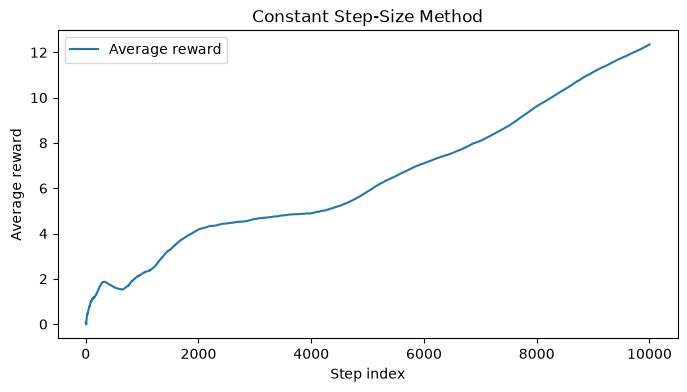

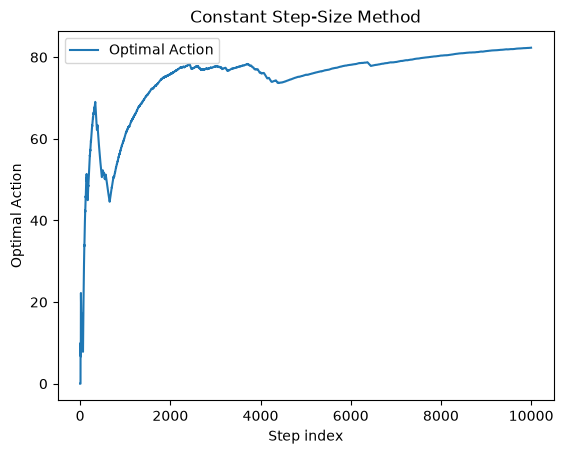

In [36]:

# #action-value method using a constant step-size parameter,  alpha = 0.1. Use epsilon = 0.1 and

epsilon = 0.1
alpha = 0.9

Q_values = np.zeros(10)
Q_star_values = np.zeros(10)

Average_Reward_History = []
optimal_action_percentage = []
time_taken_optimal_action=0
total_reward = 0

for i in range(1, 10_000):

    # True values perform a random walk
    Q_star_values += np.random.normal(0, 0.1, size=10)

    # Epsilon-greedy action selection
    if np.random.uniform(0, 1) < epsilon:
        action = np.random.choice(10)
    else:
        action = np.argmax(Q_values)

    optimal = np.argmax(Q_star_values)
    if optimal == action:
        time_taken_optimal_action +=1
    
    optimal_action_percentage.append((time_taken_optimal_action / i)*100)
    
    # Observe reward
    reward = Q_star_values[action]
    
    # Constant step-size update
    Q_values[action] += alpha * (
        reward - Q_values[action]
    )

    # Average reward
    total_reward += reward
    Average_Reward_History.append(total_reward / i)


plt.figure(figsize=(8, 4))

plt.plot(
    range(1, 10_000),
    Average_Reward_History,
    label="Average reward"
)

plt.xlabel("Step index")
plt.ylabel("Average reward")
plt.title("Constant Step-Size Method")
plt.legend()

plt.show()


plt.plot(
    range(1, 10_000),
    optimal_action_percentage,
    label="Optimal Action"
)

plt.xlabel("Step index")
plt.ylabel("Optimal Action")
plt.title("Constant Step-Size Method")
plt.legend()
plt.show()
